<a href="https://colab.research.google.com/github/23002125-glitch/IDS-Alt-Assessment-SSR-analysis-/blob/main/IDS_SSR_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Load your clean dataset
file_name = 'malaysia_ssl_price_clean.csv'

try:
    df = pd.read_csv(file_name)
    print("Dataset loaded successfully!\n")

    # 2. Extract a strategic snippet showing low SSR items and CPI
    # We slice specific rows to show a mix of categories for your infographic
    snippet = df.head(5)

    # 3. Display the snippet as a clean, styled Markdown Table
    print(snippet.to_markdown(index=False))

except FileNotFoundError:
    print(f"❌ Error: Could not find '{file_name}' in your Colab file explorer.")
    print("Please make sure you have uploaded or generated the file in this session.")


Dataset loaded successfully!

| Category   | Commodity   |   Year |   Production_tonnes |   Imports_tonnes |   Exports_tonnes |   Total_Supply_tonnes |   Food_tonnes |   Total_Utilization_tonnes |   Per_Capita_kg_year |   Net_Export_Balance_t |   Self_Sufficiency_Ratio_pct | SSL_Category                |   SSL_YoY_Change_ppt |   Import_Dependency_Ratio_pct |   Avg_Price_RM | Price_Unit   |   Price_YoY_Change_pct |
|:-----------|:------------|-------:|--------------------:|-----------------:|-----------------:|----------------------:|--------------:|---------------------------:|---------------------:|-----------------------:|-----------------------------:|:----------------------------|---------------------:|------------------------------:|---------------:|:-------------|-----------------------:|
| Fisheries  | Crab        |   2018 |             15421.9 |           5845.5 |           3530.4 |               21267.4 |       13348.9 |                    21267.4 |                  0.4 |     

In [ ]:
import pandas as pd

# 1. Load the dataset
file_name = 'malaysia_ssl_price_clean.csv'

try:
    df = pd.read_csv(file_name)
    print(f" Original shape before dropping: {df.shape}")

    # 2. List of columns you want to drop
    # (Includes variations to prevent errors due to typos like tonn/ton)
    columns_to_drop = [
        'Production_tonnes', 'Imports_tonnes',
        'Exports_tonnes', 'Total_Supply_tonnes',
        'Food_tonnes', 'Total_Utilization_tonnes',
        'Per_Capita_kg_year', 'Net_Export_Balance_t',
        'SSL_YoY_Change_ppt',
        'Price_YoY_Change_pct'
    ]

    # 3. Filter the list to only drop columns that actually exist in your file
    existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

    # 4. Drop the columns
    df_filtered = df.drop(columns=existing_columns_to_drop)

    print(f"Successfully dropped {len(existing_columns_to_drop)} columns.")
    print(f" New shape after dropping: {df_filtered.shape}\n")

    # 5. Save the newly trimmed dataset
    output_file = 'malaysia_ssl_price_final.csv'
    df_filtered.to_csv(output_file, index=False)
    print(f"Saved clean file as: '{output_file}'")

    # 6. Display the remaining columns to verify
    print("\n--- Remaining Columns for Your Infographic Snippet ---")
    print(df_filtered.columns.tolist())
    print("\n--- Top 5 Rows Sample ---")
    display(df_filtered.head())

except FileNotFoundError:
    print(f"❌ Error: Could not find '{file_name}'. Please verify it is in your Colab files panel.")

 Original shape before dropping: (260, 18)
Successfully dropped 10 columns.
 New shape after dropping: (260, 8)

Saved clean file as: 'malaysia_ssl_price_final.csv'

--- Remaining Columns for Your Infographic Snippet ---
['Category', 'Commodity', 'Year', 'Self_Sufficiency_Ratio_pct', 'SSL_Category', 'Import_Dependency_Ratio_pct', 'Avg_Price_RM', 'Price_Unit']

--- Top 5 Rows Sample ---


,Category,Commodity,Year,Self_Sufficiency_Ratio_pct,SSL_Category,Import_Dependency_Ratio_pct,Avg_Price_RM,Price_Unit
0,Fisheries,Crab,2018,86.9,Moderately Deficit (70-99%),33.0,NaN,NaN
1,Fisheries,Crab,2019,94.0,Moderately Deficit (70-99%),31.4,NaN,NaN
2,Fisheries,Crab,2020,94.3,Moderately Deficit (70-99%),32.9,29.27,kg
3,Fisheries,Crab,2021,104.4,Self-Sufficient (100-120%),36.7,29.88,kg
4,Fisheries,Crab,2022,97.8,Moderately Deficit (70-99%),23.5,32.69,kg


In [ ]:
# Drop rows that contain any null / NaN value

df = pd.read_csv('malaysia_ssl_price_final.csv')
df_cleaned = df.dropna()

output_file = 'malaysia_ssl_price_final_cleaned.csv'
df_cleaned.to_csv(output_file, index=False)
print(f"Saved clean file as: '{output_file}'")
# Check result
df_cleaned.head()



Saved clean file as: 'malaysia_ssl_price_final_cleaned.csv'


,Category,Commodity,Year,Self_Sufficiency_Ratio_pct,SSL_Category,Import_Dependency_Ratio_pct,Avg_Price_RM,Price_Unit
2,Fisheries,Crab,2020,94.3,Moderately Deficit (70-99%),32.9,29.27,kg
3,Fisheries,Crab,2021,104.4,Self-Sufficient (100-120%),36.7,29.88,kg
4,Fisheries,Crab,2022,97.8,Moderately Deficit (70-99%),23.5,32.69,kg
7,Fisheries,Cuttlefish,2020,96.6,Moderately Deficit (70-99%),52.2,26.35,kg
8,Fisheries,Cuttlefish,2021,80.0,Moderately Deficit (70-99%),65.3,29.21,kg


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv('malaysia_ssl_price_final_cleaned.csv')

# Display first few rows
print("--- Top 5 Rows ---")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("--- Dataset Information ---")
df.info()

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("--- Missing Values ---")
display(df.isnull().sum())

print("\n--- Percentage of Missing Values ---")
display((df.isnull().sum() / len(df) * 100).round(2))

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("--- Descriptive Statistics for Numerical Columns ---")
display(df.describe())

--- Top 5 Rows ---


,Category,Commodity,Year,Self_Sufficiency_Ratio_pct,SSL_Category,Import_Dependency_Ratio_pct,Avg_Price_RM,Price_Unit
0,Fisheries,Crab,2020,94.3,Moderately Deficit (70-99%),32.9,29.27,kg
1,Fisheries,Crab,2021,104.4,Self-Sufficient (100-120%),36.7,29.88,kg
2,Fisheries,Crab,2022,97.8,Moderately Deficit (70-99%),23.5,32.69,kg
3,Fisheries,Cuttlefish,2020,96.6,Moderately Deficit (70-99%),52.2,26.35,kg
4,Fisheries,Cuttlefish,2021,80.0,Moderately Deficit (70-99%),65.3,29.21,kg



Dataset Shape:
(137, 8)
--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Category                     137 non-null    object 
 1   Commodity                    137 non-null    object 
 2   Year                         137 non-null    int64  
 3   Self_Sufficiency_Ratio_pct   137 non-null    float64
 4   SSL_Category                 137 non-null    object 
 5   Import_Dependency_Ratio_pct  137 non-null    float64
 6   Avg_Price_RM                 137 non-null    float64
 7   Price_Unit                   137 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 8.7+ KB

--- Column Names ---
['Category', 'Commodity', 'Year', 'Self_Sufficiency_Ratio_pct', 'SSL_Category', 'Import_Dependency_Ratio_pct', 'Avg_Price_RM', 'Price_Unit']

--- Data Types ---
Category          

,0
Category,0
Commodity,0
Year,0
Self_Sufficiency_Ratio_pct,0
SSL_Category,0
Import_Dependency_Ratio_pct,0
Avg_Price_RM,0
Price_Unit,0



--- Percentage of Missing Values ---


,0
Category,0.0
Commodity,0.0
Year,0.0
Self_Sufficiency_Ratio_pct,0.0
SSL_Category,0.0
Import_Dependency_Ratio_pct,0.0
Avg_Price_RM,0.0
Price_Unit,0.0



--- Duplicate Rows ---
0
--- Descriptive Statistics for Numerical Columns ---


,Year,Self_Sufficiency_Ratio_pct,Import_Dependency_Ratio_pct,Avg_Price_RM
count,137.000000,137.000000,137.000000,137.000000
mean,2021.000000,84.614599,26.481483,11.249051
std,0.822478,38.157756,33.160063,8.469667
min,2020.000000,0.000000,0.000200,3.030000
25%,2020.000000,75.600000,2.300000,5.890000
50%,2021.000000,98.100000,9.700000,8.410000
75%,2022.000000,108.100000,32.900000,12.130000
max,2022.000000,156.000000,100.000000,42.550000


,Self_Sufficiency_Ratio_pct
Category,
Fruits,103.458333
Vegetables,94.090000
Fisheries,92.593333
Livestock,71.950000
Other Crops,39.438095


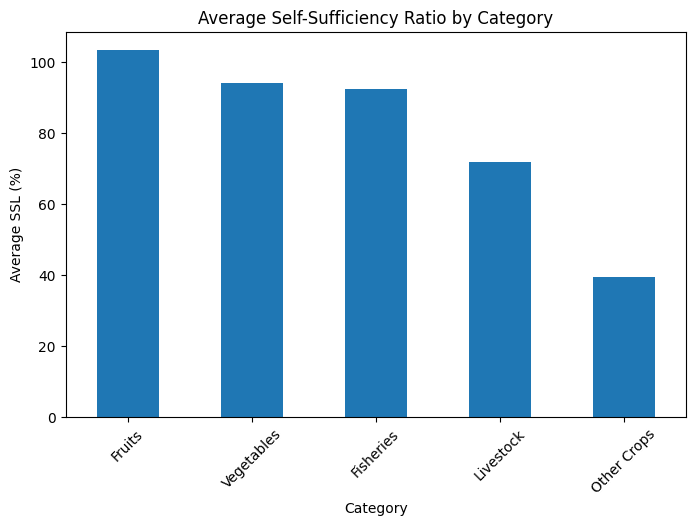

In [ ]:
avg_ssl_category = df.groupby('Category')['Self_Sufficiency_Ratio_pct'].mean().sort_values(ascending=False)

display(avg_ssl_category)

avg_ssl_category.plot(kind='bar', figsize=(8,5))

plt.title("Average Self-Sufficiency Ratio by Category")
plt.xlabel("Category")
plt.ylabel("Average SSL (%)")
plt.xticks(rotation=45)
plt.show()

,Import_Dependency_Ratio_pct
Category,
Other Crops,62.552381
Livestock,37.432260
Fisheries,19.833333
Vegetables,18.180000
Fruits,11.814389


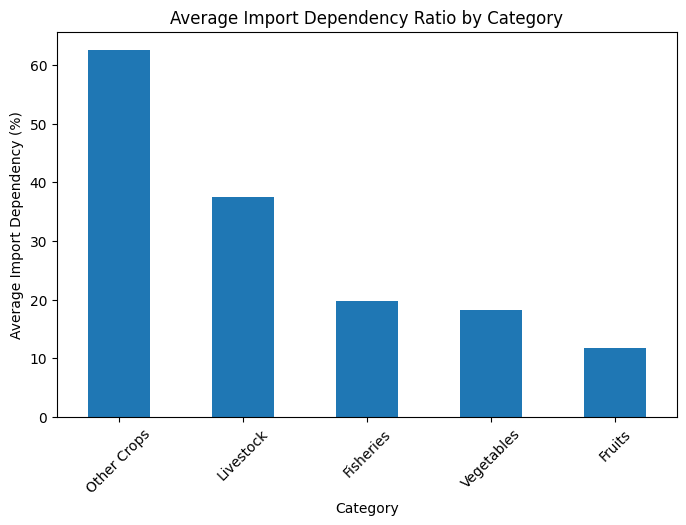

In [ ]:
avg_import_category = df.groupby('Category')['Import_Dependency_Ratio_pct'].mean().sort_values(ascending=False)

display(avg_import_category)

avg_import_category.plot(kind='bar', figsize=(8,5))

plt.title("Average Import Dependency Ratio by Category")
plt.xlabel("Category")
plt.ylabel("Average Import Dependency (%)")
plt.xticks(rotation=45)
plt.show()

,Self_Sufficiency_Ratio_pct
Year,
2020,85.817391
2021,84.891111
2022,83.141304


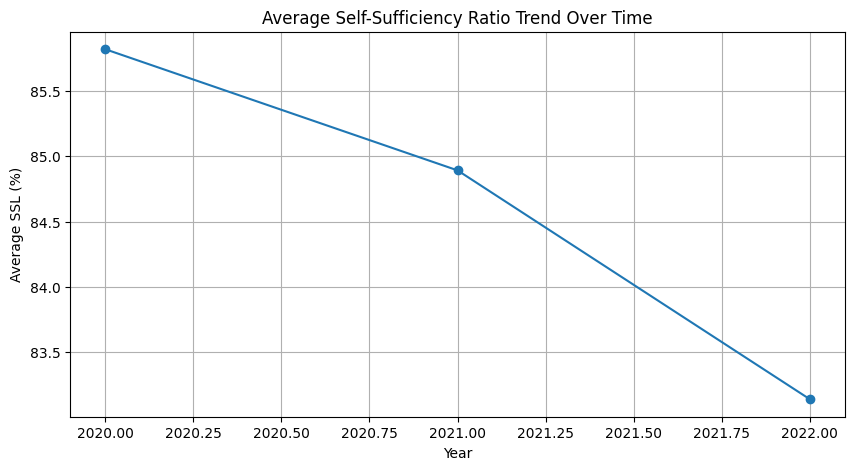

In [ ]:
ssl_trend = df.groupby('Year')['Self_Sufficiency_Ratio_pct'].mean()

display(ssl_trend)
ssl_trend.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Average Self-Sufficiency Ratio Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average SSL (%)")
plt.grid(True)
plt.show()

,Import_Dependency_Ratio_pct
Year,
2020,25.141570
2021,27.171689
2022,27.146196


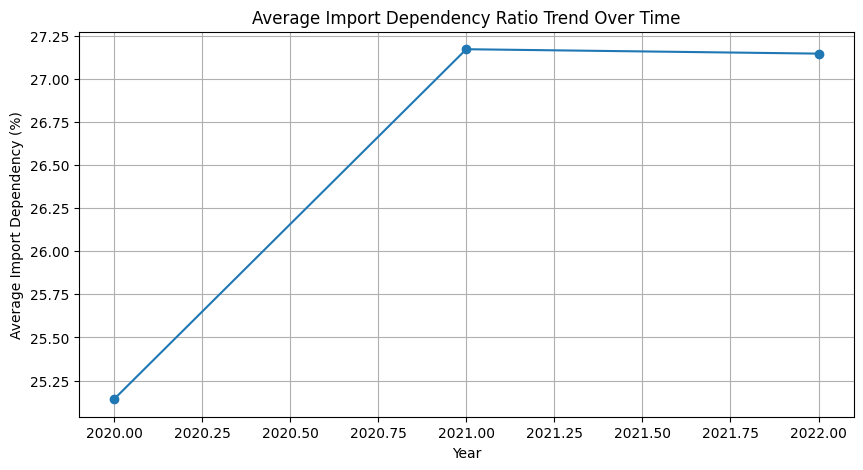

In [ ]:
import_trend = df.groupby('Year')['Import_Dependency_Ratio_pct'].mean()

display(import_trend)
import_trend.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Average Import Dependency Ratio Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Import Dependency (%)")
plt.grid(True)
plt.show()

,Avg_Price_RM
Year,
2020,10.466522
2021,11.149111
2022,12.129348


<function matplotlib.pyplot.show(close=None, block=None)>

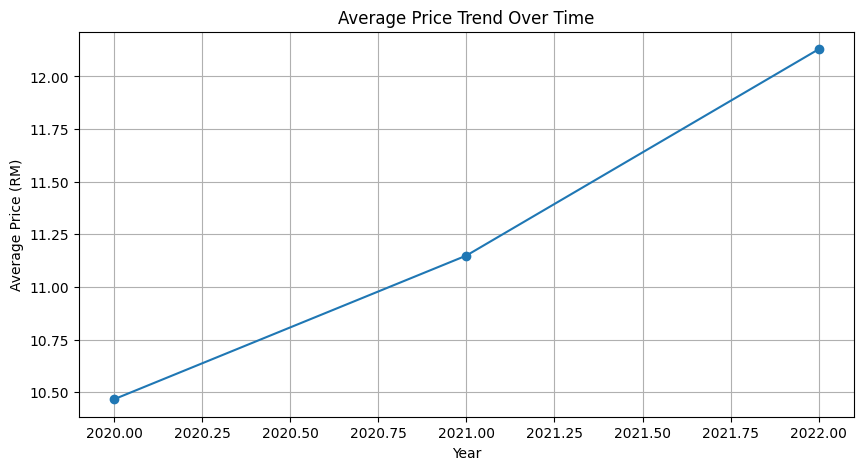

In [ ]:
price_trend = df.groupby('Year')['Avg_Price_RM'].mean()

display(price_trend)

price_trend.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Average Price Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price (RM)")
plt.grid(True)
plt.show

,Self_Sufficiency_Ratio_pct
Commodity,
Papaya,148.400000
Watermelon,136.933333
Duck Meat,128.666667
Tomato,120.200000
Starfruit,118.166667
Jackfruit,111.633333
Eggs,111.500000
Cucumber,111.466667
Spinach,111.200000


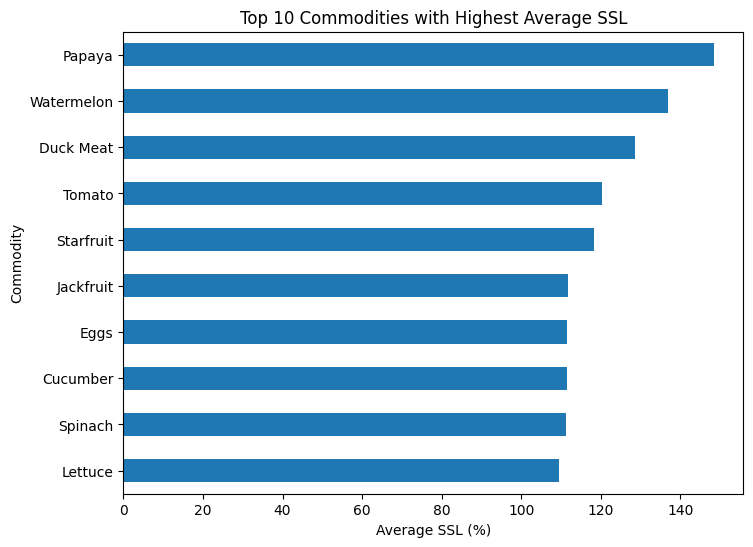

In [ ]:
top_ssl = df.groupby('Commodity')['Self_Sufficiency_Ratio_pct'].mean().sort_values(ascending=False).head(10)

display(top_ssl)
top_ssl.plot(kind='barh', figsize=(8,6))

plt.title("Top 10 Commodities with Highest Average SSL")
plt.xlabel("Average SSL (%)")
plt.ylabel("Commodity")
plt.gca().invert_yaxis()
plt.show()

,Self_Sufficiency_Ratio_pct
Commodity,
Garlic,0.000000
Onion,0.000000
Shallot,0.000000
Mutton,9.600000
Ginger,16.466667
Beef/Buffalo,18.300000
Mango,22.800000
Chilli,29.966667
Round Cabbage,41.133333


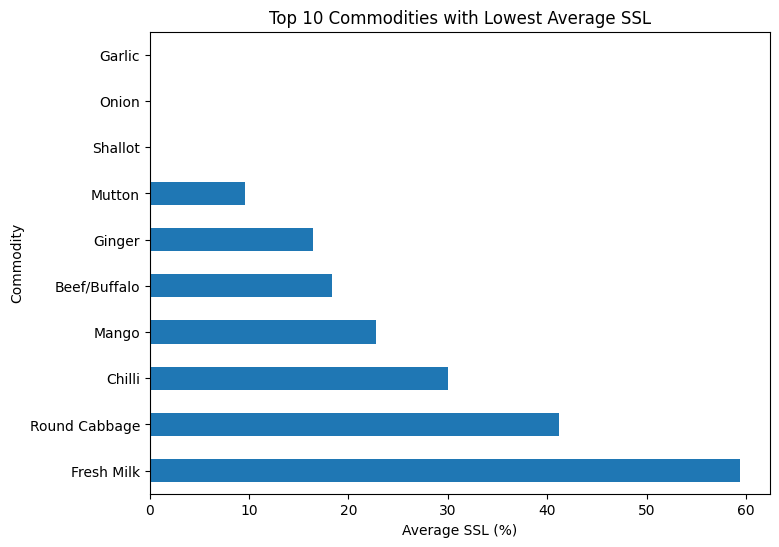

In [ ]:
low_ssl = df.groupby('Commodity')['Self_Sufficiency_Ratio_pct'].mean().sort_values(ascending=True).head(10)

display(low_ssl)
low_ssl.plot(kind='barh', figsize=(8,6))

plt.title("Top 10 Commodities with Lowest Average SSL")
plt.xlabel("Average SSL (%)")
plt.ylabel("Commodity")
plt.gca().invert_yaxis()
plt.show()

,Import_Dependency_Ratio_pct
Commodity,
Onion,100.000000
Garlic,100.000000
Shallot,100.000000
Mutton,90.500000
Mango,86.166667
Ginger,84.533333
Beef/Buffalo,82.066667
Chilli,73.833333
Cuttlefish,62.700000


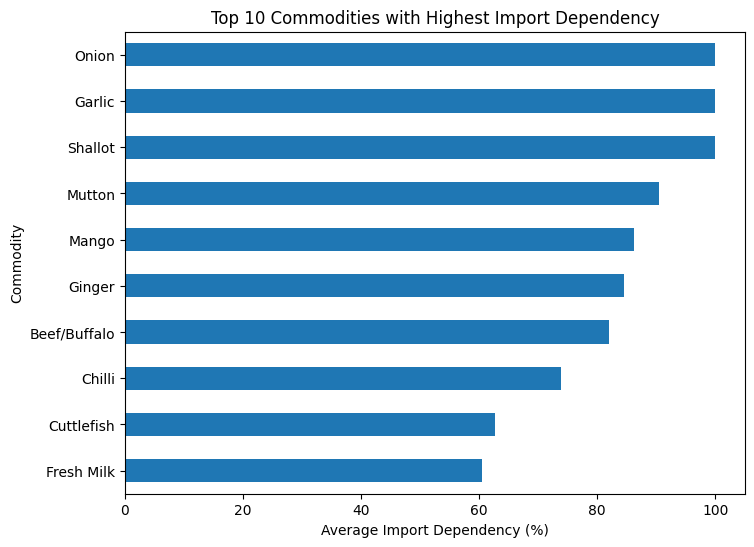

In [ ]:
top_import = df.groupby('Commodity')['Import_Dependency_Ratio_pct'].mean().sort_values(ascending=False).head(10)

display(top_import)
top_import.plot(kind='barh', figsize=(8,6))

plt.title("Top 10 Commodities with Highest Import Dependency")
plt.xlabel("Average Import Dependency (%)")
plt.ylabel("Commodity")
plt.gca().invert_yaxis()
plt.show()

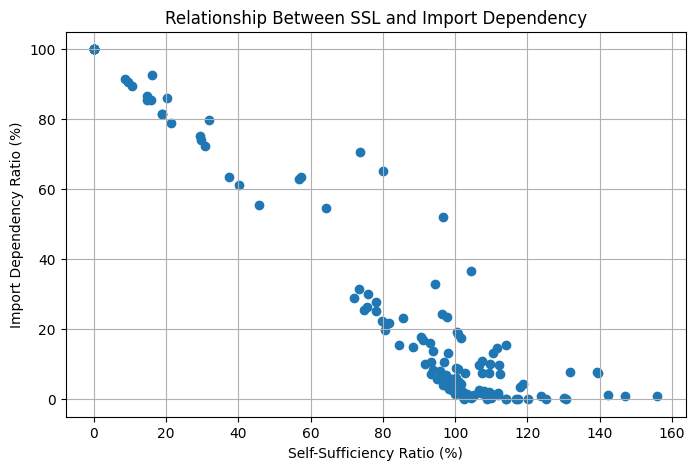

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Self_Sufficiency_Ratio_pct'],
    df['Import_Dependency_Ratio_pct']
)

plt.title("Relationship Between SSL and Import Dependency")
plt.xlabel("Self-Sufficiency Ratio (%)")
plt.ylabel("Import Dependency Ratio (%)")
plt.grid(True)
plt.show()

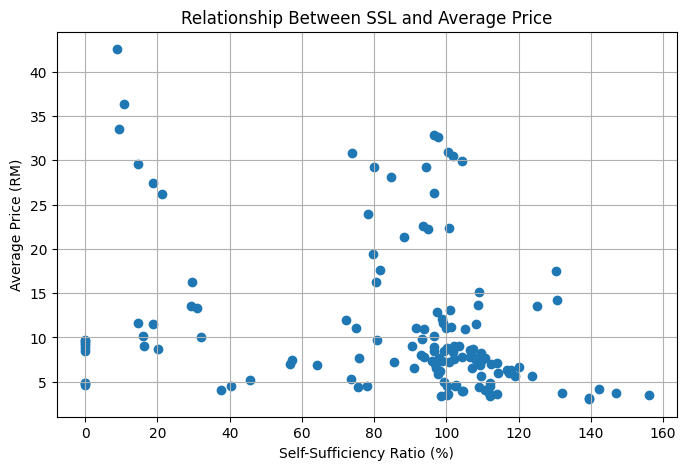

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Self_Sufficiency_Ratio_pct'],
    df['Avg_Price_RM']
)

plt.title("Relationship Between SSL and Average Price")
plt.xlabel("Self-Sufficiency Ratio (%)")
plt.ylabel("Average Price (RM)")
plt.grid(True)
plt.show()